In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import os
import joblib

In [2]:
import mlflow
import mlflow.xgboost

mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("turbofan-rul-prediction")

mlflow.set_experiment("turbofan-rul-prediction")

2026/07/19 20:23:18 INFO mlflow.tracking.fluent: Experiment with name 'turbofan-rul-prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='/Users/arpita/Desktop/projects/industrial-predictive-maintenance/notebooks/mlruns/1', creation_time=1784506998989, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1784506998989, lifecycle_stage='active', name='turbofan-rul-prediction', tags={}, trace_location=None, workspace='default'>

**Load processed data**

In [3]:
sensor_cols_to_use = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 
                       'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
                       'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
                       'sensor_20', 'sensor_21']

In [4]:
DATA_DIR = Path.cwd().parent / 'data' / 'processed'
train_split = pd.read_csv(DATA_DIR / 'train_split.csv')
val_split = pd.read_csv(DATA_DIR / 'val_split.csv')

feature_cols = sensor_cols_to_use + [f'{s}_rollmean' for s in sensor_cols_to_use] + \
               [f'{s}_rollstd' for s in sensor_cols_to_use]
print(f"Using {len(feature_cols)} features")

Using 42 features


**Regression Model**

In [5]:
mlflow.start_run(run_name="xgboost-regressor")

mlflow.log_params({
    "n_estimators": 100,
    "max_depth": 5,
    "learning_rate": 0.1,
    "n_features": len(feature_cols),
})

X_train = train_split[feature_cols]
y_train = train_split['RUL']
X_val = val_split[feature_cols]
y_val = val_split['RUL']

reg_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
reg_model.fit(X_train, y_train)

preds = reg_model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
mae = mean_absolute_error(y_val, preds)
mlflow.log_metrics({"rmse": rmse, "mae": mae})
print(f"RMSE: {rmse:.2f} cycles")
print(f"MAE: {mae:.2f} cycles")

RMSE: 34.40 cycles
MAE: 24.71 cycles


In [6]:
xgb_val_preds = pd.DataFrame({
    'unit': val_split['unit'],
    'cycle': val_split['cycle'],
    'xgb_pred': reg_model.predict(val_split[feature_cols])
})
xgb_val_preds.to_csv('../data/processed/xgb_val_predictions.csv', index=False)
print(xgb_val_preds.shape)

(4070, 3)


**Feature importance**

sensor_4_rollmean     0.234405
sensor_11_rollmean    0.163984
sensor_15_rollmean    0.144729
sensor_21_rollmean    0.105256
sensor_9_rollmean     0.052405
sensor_20_rollmean    0.033265
sensor_2_rollmean     0.023858
sensor_14_rollmean    0.017569
sensor_3_rollmean     0.017106
sensor_7_rollmean     0.016006
dtype: float32


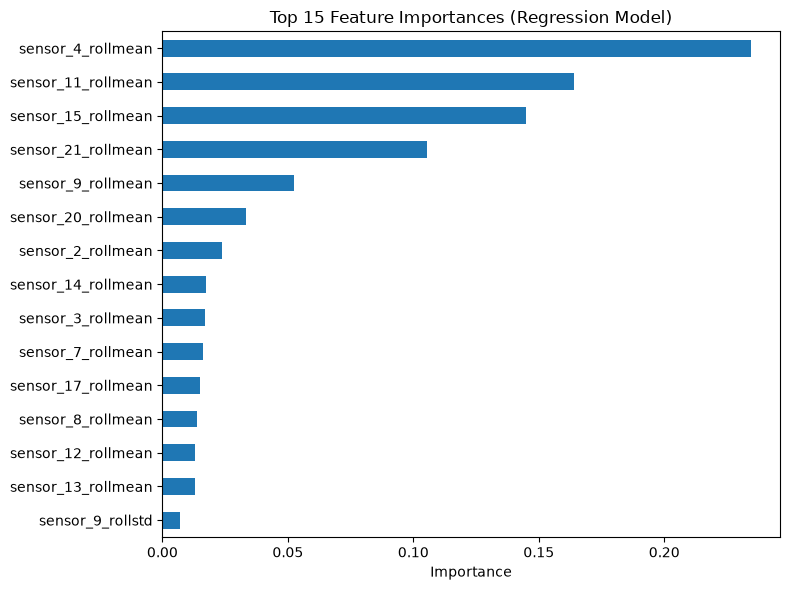

2026/07/19 20:23:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'turbofan-xgb-regressor'.
Created version '1' of model 'turbofan-xgb-regressor'.


In [7]:
importances = pd.Series(reg_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances.head(10))

importances.head(15).plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Regression Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', bbox_inches='tight')
plt.show()

mlflow.log_artifact('/tmp/feature_importance.png')
mlflow.xgboost.log_model(reg_model, artifact_path="model", registered_model_name="turbofan-xgb-regressor")
mlflow.end_run()

In [8]:
threshold = 30
train_split['fail_within_30'] = (train_split['RUL'] <= threshold).astype(int)
val_split['fail_within_30'] = (val_split['RUL'] <= threshold).astype(int)

**Classification**

In [9]:
mlflow.start_run(run_name="xgboost-classifier")

mlflow.log_params({
    "n_estimators": 100,
    "max_depth": 5,
    "learning_rate": 0.1,
})

y_train_clf = train_split['fail_within_30']
y_val_clf = val_split['fail_within_30']

clf_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
clf_model.fit(X_train, y_train_clf)

clf_preds = clf_model.predict(X_val)
clf_probs = clf_model.predict_proba(X_val)[:, 1]

mlflow.log_metrics({
    "precision": precision_score(y_val_clf, clf_preds),
    "recall": recall_score(y_val_clf, clf_preds),
    "f1": f1_score(y_val_clf, clf_preds),
    "roc_auc": roc_auc_score(y_val_clf, clf_probs),
})

print(f"Precision: {precision_score(y_val_clf, clf_preds):.3f}")
print(f"Recall: {recall_score(y_val_clf, clf_preds):.3f}")
print(f"F1: {f1_score(y_val_clf, clf_preds):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_val_clf, clf_probs):.3f}")
print("\nConfusion matrix:")
print(confusion_matrix(y_val_clf, clf_preds))

Precision: 0.903
Recall: 0.858
F1: 0.880
ROC-AUC: 0.991

Confusion matrix:
[[3393   57]
 [  88  532]]


**Threshold adjustment**

In [10]:
threshold = 0.3  # more sensitive to catching potential failures
clf_preds_adjusted = (clf_probs >= threshold).astype(int)

adj_precision = precision_score(y_val_clf, clf_preds_adjusted)
adj_recall = recall_score(y_val_clf, clf_preds_adjusted)

mlflow.log_params({"adjusted_threshold": threshold})
mlflow.log_metrics({
    "precision_at_threshold": adj_precision,
    "recall_at_threshold": adj_recall,
})
mlflow.xgboost.log_model(clf_model, artifact_path="model")
mlflow.end_run()

print(f"At threshold={threshold}:")
print(f"Precision: {adj_precision:.3f}")
print(f"Recall: {adj_recall:.3f}")

2026/07/19 20:23:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


At threshold=0.3:
Precision: 0.805
Recall: 0.916


Lowered the classification threshold from 0.5 to 0.3 to prioritize recall over precision, reflecting that missing a genuine failure (false negative) carries a much higher real-world cost than an unnecessary inspection (false positive).

**Save model**

In [11]:
os.makedirs('../models', exist_ok=True)

reg_model.save_model('../models/xgb_regressor.json')
clf_model.save_model('../models/xgb_classifier.json')

scaler = joblib.load('../models/scaler.joblib')  # loading fitted scaler

In [12]:
serving_bundle = {
    'feature_cols': feature_cols,              # exact column order the model expects — order matters for XGBoost
    'sensor_cols_to_use': sensor_cols_to_use,   # the 14 sensors that get rolling stats computed
    'window': 5,                                # matches the rolling window used in 01_eda.ipynb
    'scaler': scaler,
}

joblib.dump(serving_bundle, '../models/serving_bundle.joblib')
reg_model.save_model('../models/serving_xgb_regressor.json')

print("Bundled", len(feature_cols), "features")

Bundled 42 features
